In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

model_names = ['MobileNetV2', 'ResNet50', 'EfficientNetB7']
model_categories = ['Lightweight', 'Standard', 'Advanced']

parameter_counts_M = np.array([2.27, 23.61, 64.12])

test_accuracies = np.array([77.38, 81.53, 79.08])

inference_times_ms = np.array([0.18, 0.25, 0.85])

training_time_s = np.array([210, 410, 1740])

In [ ]:
print("--- FINAL MODEL COMPARISON TABLE ---")

df = pd.DataFrame({
    'Model': model_names,
    'Category': model_categories,
    'Test Accuracy (%)': test_accuracies,
    'Parameter Count (M)': parameter_counts_M,
    'Inference Time (ms/img)': inference_times_ms
})

print(df.to_markdown(index=False, floatfmt=".2f"))

--- FINAL MODEL COMPARISON TABLE ---
| Model          | Category    |   Test Accuracy (%) |   Parameter Count (M) |   Inference Time (ms/img) |
|:---------------|:------------|--------------------:|----------------------:|--------------------------:|
| MobileNetV2    | Lightweight |               77.38 |                  2.27 |                      0.18 |
| ResNet50       | Standard    |               81.53 |                 23.61 |                      0.25 |
| EfficientNetB7 | Advanced    |               79.08 |                 64.12 |                      0.85 |


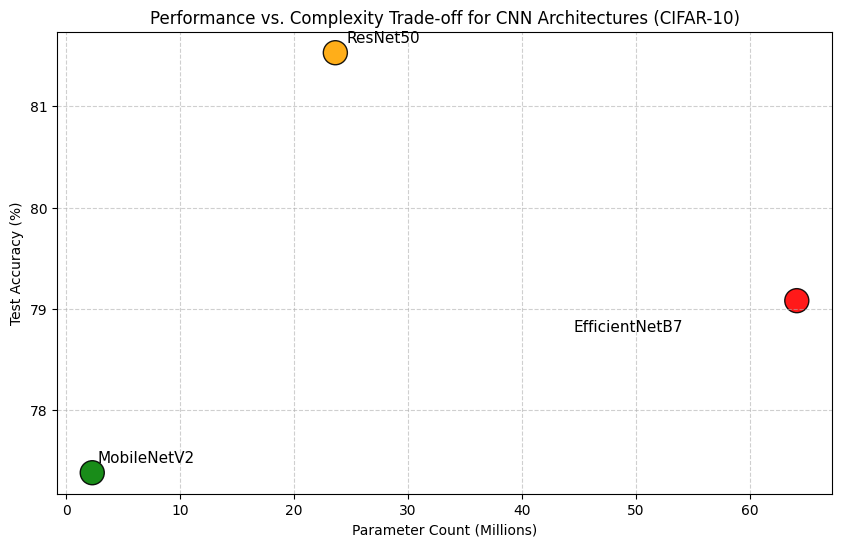

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(parameter_counts_M, test_accuracies, c=['green', 'orange', 'red'], s=300, alpha=0.9, edgecolors='black')

plt.xlabel('Parameter Count (Millions)')
plt.ylabel('Test Accuracy (%)')
plt.title('Performance vs. Complexity Trade-off for CNN Architectures (CIFAR-10)')
plt.grid(True, linestyle='--', alpha=0.6)

for i, name in enumerate(model_names):
    if name == 'MobileNetV2':
        x_offset, y_offset = 0.5, 0.1
    elif name == 'EfficientNetB7':
        x_offset, y_offset = -10, -0.3
    else:
        x_offset, y_offset = 1, 0.1

    plt.annotate(
        f'{name}',
        (parameter_counts_M[i] + x_offset, test_accuracies[i] + y_offset),
        fontsize=11,
        ha='left' if name != 'EfficientNetB7' else 'right'
    )

plt.show()

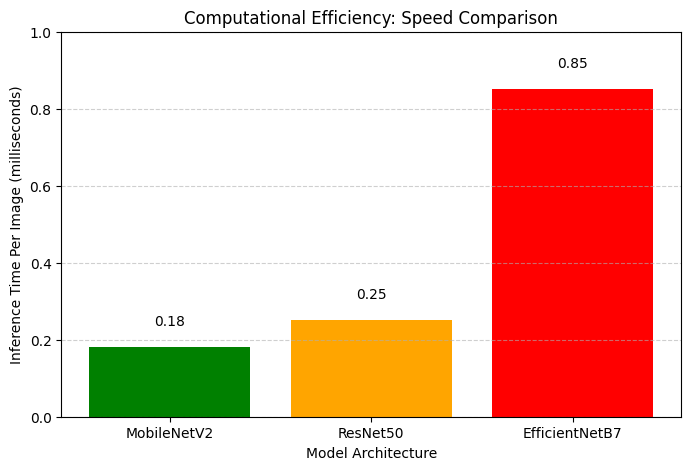

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, inference_times_ms, color=['green', 'orange', 'red'])

plt.xlabel('Model Architecture')
plt.ylabel('Inference Time Per Image (milliseconds)')
plt.title('Computational Efficiency: Speed Comparison')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom')

plt.ylim(0, 1.0)
plt.show()

Epoch history plots generated successfully and saved as 'epoch_training_history.png'.


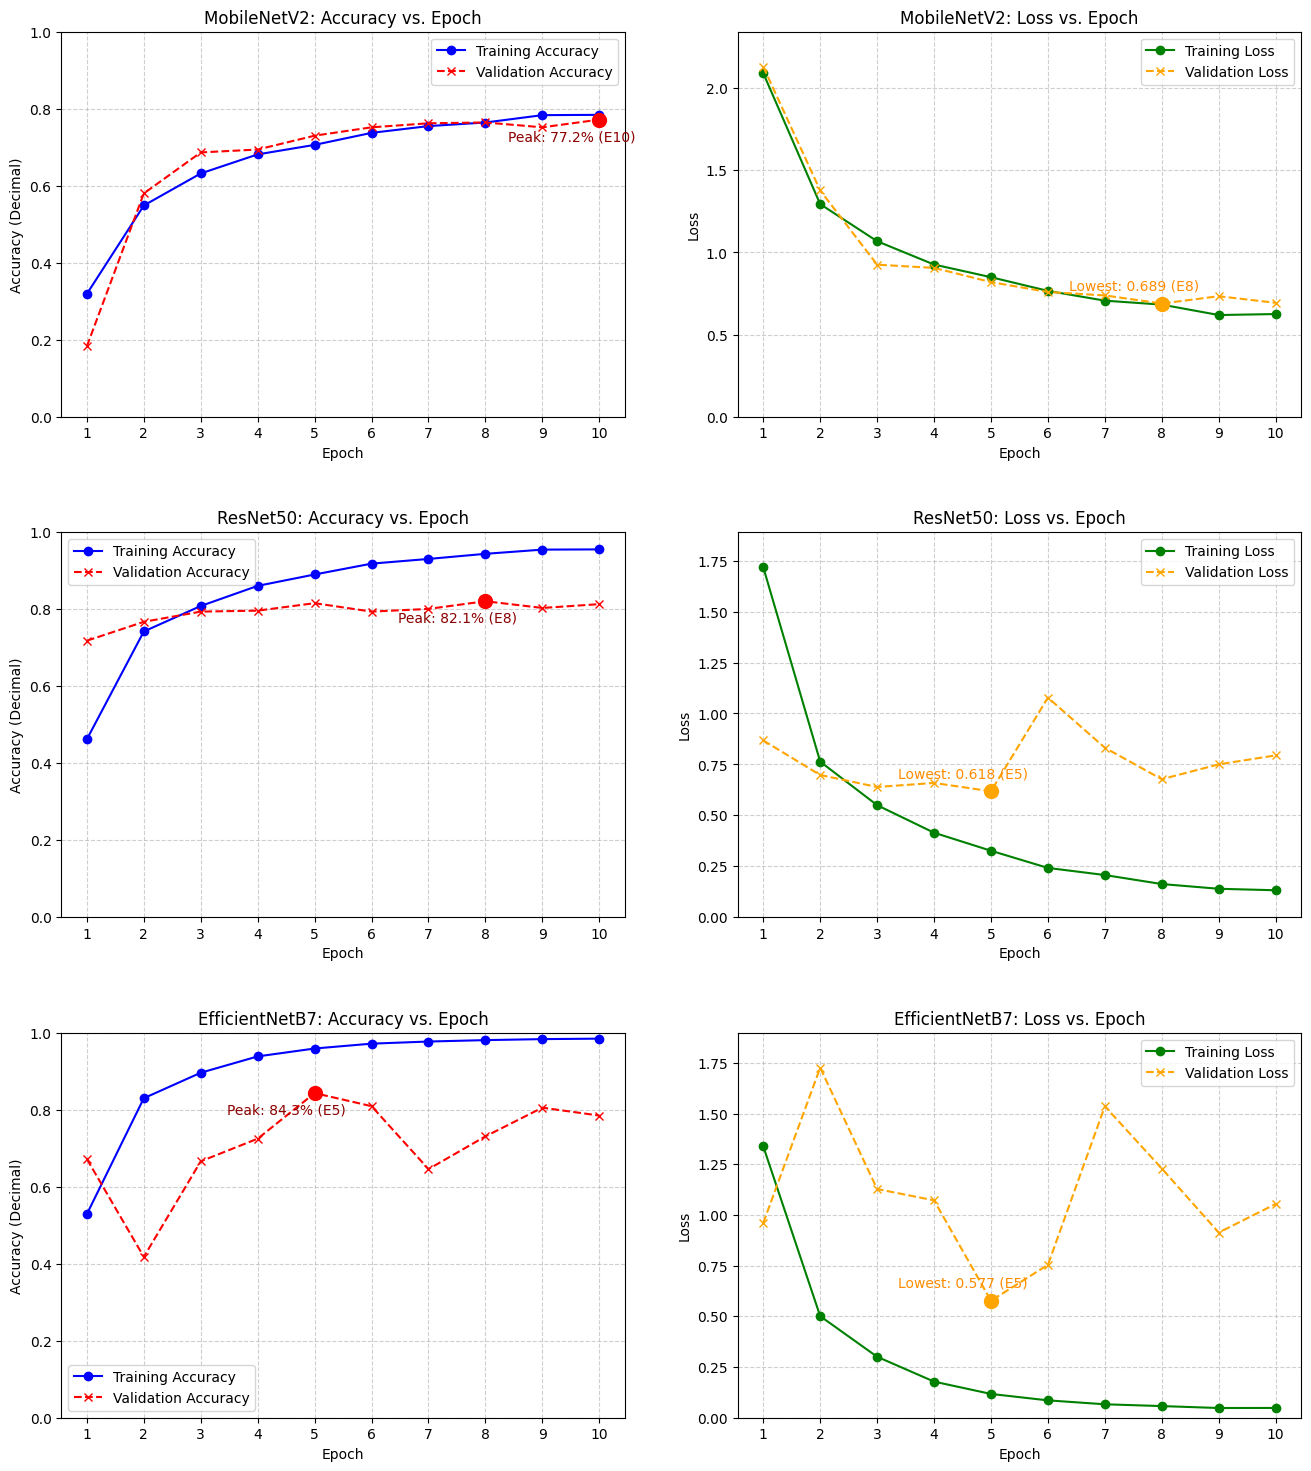

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 11)

mnv2_acc = [0.3191, 0.5487, 0.6319, 0.6814, 0.7061, 0.7373, 0.7549, 0.7642, 0.7833, 0.7841]
mnv2_val_acc = [0.1832, 0.5800, 0.6865, 0.6940, 0.7300, 0.7517, 0.7622, 0.7643, 0.7517, 0.7717]
mnv2_loss = [2.0913, 1.2942, 1.0683, 0.9263, 0.8494, 0.7660, 0.7065, 0.6825, 0.6190, 0.6250]
mnv2_val_loss = [2.1306, 1.3774, 0.9255, 0.9060, 0.8193, 0.7593, 0.7384, 0.6891, 0.7335, 0.6934]

res50_acc = [0.4623, 0.7422, 0.8084, 0.8607, 0.8902, 0.9184, 0.9306, 0.9439, 0.9548, 0.9554]
res50_val_acc = [0.7182, 0.7673, 0.7938, 0.7963, 0.8157, 0.7938, 0.8008, 0.8208, 0.8033, 0.8132]
res50_loss = [1.7176, 0.7634, 0.5499, 0.4147, 0.3262, 0.2419, 0.2070, 0.1628, 0.1396, 0.1323]
res50_val_loss = [0.8675, 0.6979, 0.6391, 0.6590, 0.6180, 1.0778, 0.8316, 0.6773, 0.7502, 0.7942]

effb7_acc = [0.5290, 0.8299, 0.8961, 0.9385, 0.9590, 0.9716, 0.9771, 0.9808, 0.9834, 0.9846]
effb7_val_acc = [0.6718, 0.4178, 0.6660, 0.7248, 0.8432, 0.8092, 0.6458, 0.7308, 0.8053, 0.7848]
effb7_loss = [1.3385, 0.5009, 0.3007, 0.1781, 0.1173, 0.0856, 0.0663, 0.0574, 0.0479, 0.0482]
effb7_val_loss = [0.9606, 1.7263, 1.1279, 1.0721, 0.5770, 0.7541, 1.5361, 1.2291, 0.9133, 1.0542]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plot_data = [
    ('MobileNetV2', mnv2_acc, mnv2_val_acc, mnv2_loss, mnv2_val_loss, 0),
    ('ResNet50', res50_acc, res50_val_acc, res50_loss, res50_val_loss, 1),
    ('EfficientNetB7', effb7_acc, effb7_val_acc, effb7_loss, effb7_val_loss, 2)
]

for name, acc, val_acc, loss, val_loss, row in plot_data:
    ax_acc = axes[row, 0]
    ax_acc.plot(epochs, acc, label='Training Accuracy', marker='o', linestyle='-', color='blue')
    ax_acc.plot(epochs, val_acc, label='Validation Accuracy', marker='x', linestyle='--', color='red')

    best_val_acc_epoch = np.argmax(val_acc) + 1
    best_val_acc = np.max(val_acc)
    ax_acc.scatter(best_val_acc_epoch, best_val_acc, color='red', s=100, zorder=5)
    ax_acc.annotate(f'Peak: {best_val_acc*100:.1f}% (E{best_val_acc_epoch})',
                    (best_val_acc_epoch, best_val_acc), textcoords="offset points", xytext=(-20,-15), ha='center', fontsize=10, color='darkred')

    ax_acc.set_title(f'{name}: Accuracy vs. Epoch')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy (Decimal)')
    ax_acc.set_xticks(epochs)
    ax_acc.legend()
    ax_acc.grid(True, linestyle='--', alpha=0.6)
    ax_acc.set_ylim(0.0, 1.0)

    ax_loss = axes[row, 1]
    ax_loss.plot(epochs, loss, label='Training Loss', marker='o', linestyle='-', color='green')
    ax_loss.plot(epochs, val_loss, label='Validation Loss', marker='x', linestyle='--', color='orange')

    best_val_loss_epoch = np.argmin(val_loss) + 1
    best_val_loss = np.min(val_loss)
    ax_loss.scatter(best_val_loss_epoch, best_val_loss, color='orange', s=100, zorder=5)
    ax_loss.annotate(f'Lowest: {best_val_loss:.3f} (E{best_val_loss_epoch})',
                     (best_val_loss_epoch, best_val_loss), textcoords="offset points", xytext=(-20,10), ha='center', fontsize=10, color='darkorange')


    ax_loss.set_title(f'{name}: Loss vs. Epoch')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_xticks(epochs)
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.6)

    max_loss = np.max([np.max(loss), np.max(val_loss)])
    ax_loss.set_ylim(0, max_loss * 1.1)

plt.savefig('epoch_training_history.png')
print("Epoch history plots generated successfully and saved as 'epoch_training_history.png'.")

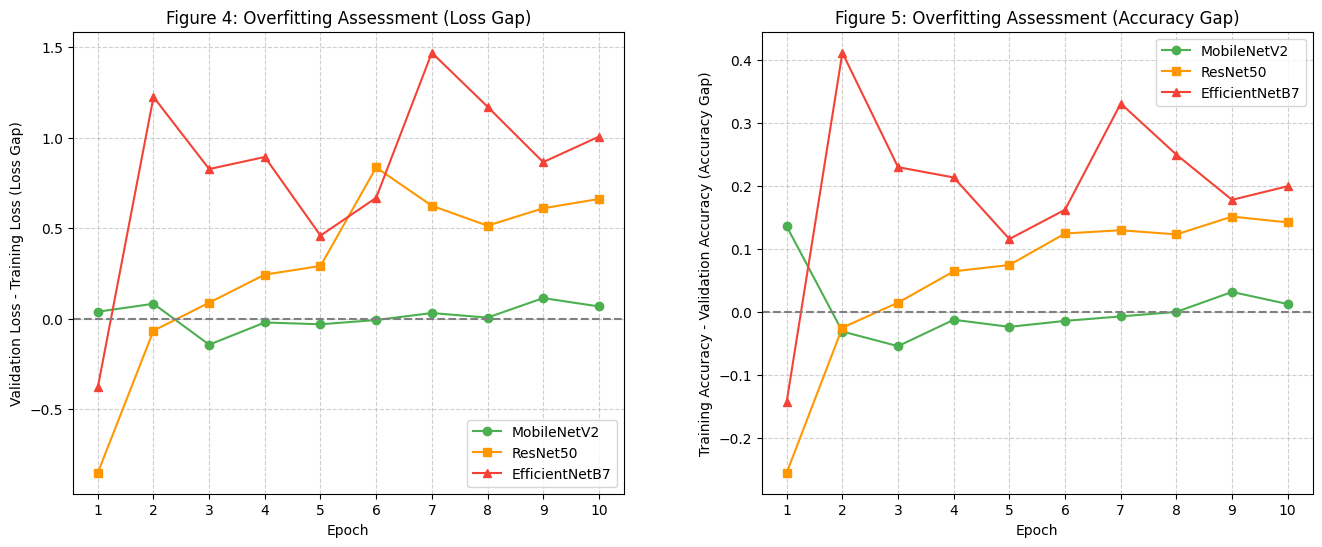

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

epochs = np.arange(1, 11)

mnv2_acc = np.array([0.3191, 0.5487, 0.6319, 0.6814, 0.7061, 0.7373, 0.7549, 0.7642, 0.7833, 0.7841])
mnv2_val_acc = np.array([0.1832, 0.5800, 0.6865, 0.6940, 0.7300, 0.7517, 0.7622, 0.7643, 0.7517, 0.7717])
mnv2_loss = np.array([2.0913, 1.2942, 1.0683, 0.9263, 0.8494, 0.7660, 0.7065, 0.6825, 0.6190, 0.6250])
mnv2_val_loss = np.array([2.1306, 1.3774, 0.9255, 0.9060, 0.8193, 0.7593, 0.7384, 0.6891, 0.7335, 0.6934])

res50_acc = np.array([0.4623, 0.7422, 0.8084, 0.8607, 0.8902, 0.9184, 0.9306, 0.9439, 0.9548, 0.9554])
res50_val_acc = np.array([0.7182, 0.7673, 0.7938, 0.7963, 0.8157, 0.7938, 0.8008, 0.8208, 0.8033, 0.8132])
res50_loss = np.array([1.7176, 0.7634, 0.5499, 0.4147, 0.3262, 0.2419, 0.2070, 0.1628, 0.1396, 0.1323])
res50_val_loss = np.array([0.8675, 0.6979, 0.6391, 0.6590, 0.6180, 1.0778, 0.8316, 0.6773, 0.7502, 0.7942])

effb7_acc = np.array([0.5290, 0.8299, 0.8961, 0.9385, 0.9590, 0.9716, 0.9771, 0.9808, 0.9834, 0.9846])
effb7_val_acc = np.array([0.6718, 0.4178, 0.6660, 0.7248, 0.8432, 0.8092, 0.6458, 0.7308, 0.8053, 0.7848])
effb7_loss = np.array([1.3385, 0.5009, 0.3007, 0.1781, 0.1173, 0.0856, 0.0663, 0.0574, 0.0479, 0.0482])
effb7_val_loss = np.array([0.9606, 1.7263, 1.1279, 1.0721, 0.5770, 0.7541, 1.5361, 1.2291, 0.9133, 1.0542])

mnv2_loss_gap = mnv2_val_loss - mnv2_loss
res50_loss_gap = res50_val_loss - res50_loss
effb7_loss_gap = effb7_val_loss - effb7_loss

mnv2_acc_gap = mnv2_acc - mnv2_val_acc
res50_acc_gap = res50_acc - res50_val_acc
effb7_acc_gap = effb7_acc - effb7_val_acc


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.25)

ax_loss = axes[0]
ax_loss.plot(epochs, mnv2_loss_gap, label='MobileNetV2', marker='o', color='#4CAF50')
ax_loss.plot(epochs, res50_loss_gap, label='ResNet50', marker='s', color='#FF9800')
ax_loss.plot(epochs, effb7_loss_gap, label='EfficientNetB7', marker='^', color='#F44336')

ax_loss.axhline(0, color='gray', linestyle='--')
ax_loss.set_title('Figure 4: Overfitting Assessment (Loss Gap)')
ax_loss.set_xlabel('Epoch')
ax_loss.set_ylabel('Validation Loss - Training Loss (Loss Gap)')
ax_loss.set_xticks(epochs)
ax_loss.legend()
ax_loss.grid(True, linestyle='--', alpha=0.6)


ax_acc = axes[1]
ax_acc.plot(epochs, mnv2_acc_gap, label='MobileNetV2', marker='o', color='#4CAF50')
ax_acc.plot(epochs, res50_acc_gap, label='ResNet50', marker='s', color='#FF9800')
ax_acc.plot(epochs, effb7_acc_gap, label='EfficientNetB7', marker='^', color='#F44336')

ax_acc.axhline(0, color='gray', linestyle='--')
ax_acc.set_title('Figure 5: Overfitting Assessment (Accuracy Gap)')
ax_acc.set_xlabel('Epoch')
ax_acc.set_ylabel('Training Accuracy - Validation Accuracy (Accuracy Gap)')
ax_acc.set_xticks(epochs)
ax_acc.legend()
ax_acc.grid(True, linestyle='--', alpha=0.6)

plt.show()

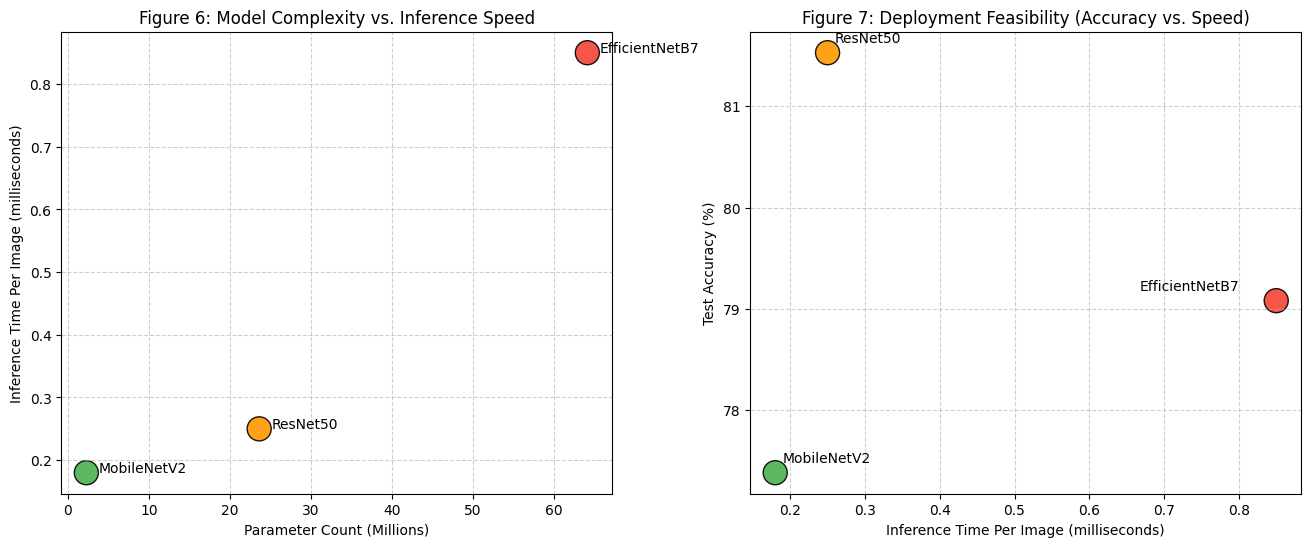

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

model_names = ['MobileNetV2', 'ResNet50', 'EfficientNetB7']
colors = ['#4CAF50', '#FF9800', '#F44336']

parameter_counts_M = np.array([2.27, 23.61, 64.12])
test_accuracies = np.array([77.38, 81.53, 79.08])
inference_times_ms = np.array([0.18, 0.25, 0.85])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.subplots_adjust(wspace=0.25)

ax_param_speed = axes[0]
ax_param_speed.scatter(parameter_counts_M, inference_times_ms, c=colors, s=300, alpha=0.9, edgecolors='black')

ax_param_speed.set_title('Figure 6: Model Complexity vs. Inference Speed')
ax_param_speed.set_xlabel('Parameter Count (Millions)')
ax_param_speed.set_ylabel('Inference Time Per Image (milliseconds)')
ax_param_speed.grid(True, linestyle='--', alpha=0.6)

for i, name in enumerate(model_names):
    ax_param_speed.annotate(
        name,
        (parameter_counts_M[i] + 1.5, inference_times_ms[i]),
        fontsize=10,
        ha='left'
    )

ax_acc_speed = axes[1]
ax_acc_speed.scatter(inference_times_ms, test_accuracies, c=colors, s=300, alpha=0.9, edgecolors='black')

ax_acc_speed.set_title('Figure 7: Deployment Feasibility (Accuracy vs. Speed)')
ax_acc_speed.set_xlabel('Inference Time Per Image (milliseconds)')
ax_acc_speed.set_ylabel('Test Accuracy (%)')
ax_acc_speed.grid(True, linestyle='--', alpha=0.6)

for i, name in enumerate(model_names):
    if name == 'EfficientNetB7':
        x_offset, y_offset = -0.05, 0.1
        ha = 'right'
    else:
        x_offset, y_offset = 0.01, 0.1
        ha = 'left'

    ax_acc_speed.annotate(
        name,
        (inference_times_ms[i] + x_offset, test_accuracies[i] + y_offset),
        fontsize=10,
        ha=ha
    )

plt.show()

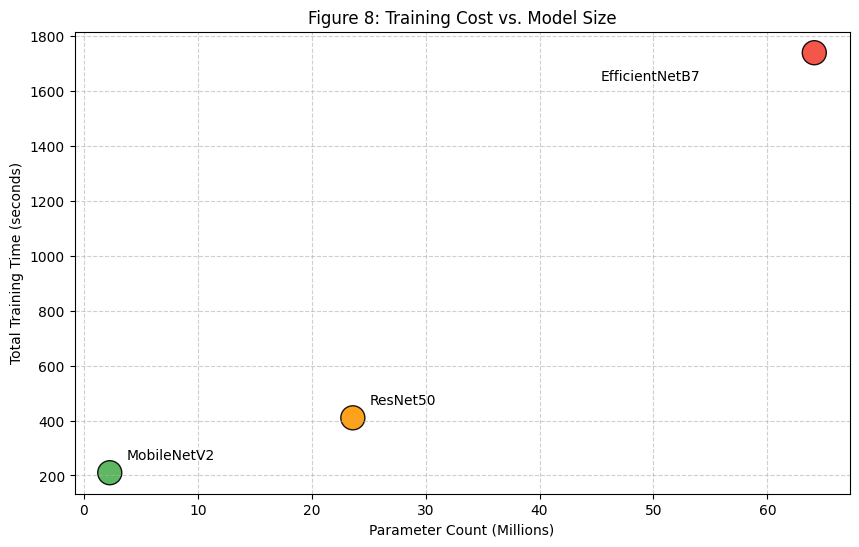

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

model_names = ['MobileNetV2', 'ResNet50', 'EfficientNetB7']
colors = ['#4CAF50', '#FF9800', '#F44336']

parameter_counts_M = np.array([2.27, 23.61, 64.12])

total_training_time_s = np.array([210, 410, 1740])

plt.figure(figsize=(10, 6))
plt.scatter(parameter_counts_M, total_training_time_s, c=colors, s=300, alpha=0.9, edgecolors='black')

plt.title('Figure 8: Training Cost vs. Model Size')
plt.xlabel('Parameter Count (Millions)')
plt.ylabel('Total Training Time (seconds)')
plt.grid(True, linestyle='--', alpha=0.6)

for i, name in enumerate(model_names):
    x_offset, y_offset = (1.5, 50) if name != 'EfficientNetB7' else (-10, -100)
    ha = 'left' if name != 'EfficientNetB7' else 'right'

    plt.annotate(
        f'{name}',
        (parameter_counts_M[i] + x_offset, total_training_time_s[i] + y_offset),
        fontsize=10,
        ha=ha
    )

plt.show()